# Explicación de predicciones para una Red Neuronal usando Gradients Integrados

- Integrantes: Felipe Peralta, Samantha Suquilanda

## Carga de Librerías y Datos

In [26]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
df = pd.read_csv('../data/online+shoppers+purchasing+intention+dataset/online_shoppers_intention.csv')

## Análisis Exploratorio de Datos

In [4]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [5]:
print(f"Dimensiones del dataset: {df.shape}")
print("Tipos de datos y nulos:")
print(df.info())

Dimensiones del dataset: (12330, 18)
Tipos de datos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region         

In [6]:
print("Estadísticas:")
display(df.describe())

Estadísticas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [7]:
# mirar nulos y duplicados
nulos = df.isnull().sum().sum()
duplicados = df.duplicated().sum()
print(f"Total de valores nulos: {nulos}")
print(f"Filas duplicadas: {duplicados}")

Total de valores nulos: 0
Filas duplicadas: 125


In [8]:
# borrar duplicados
df.drop_duplicates(inplace=True)

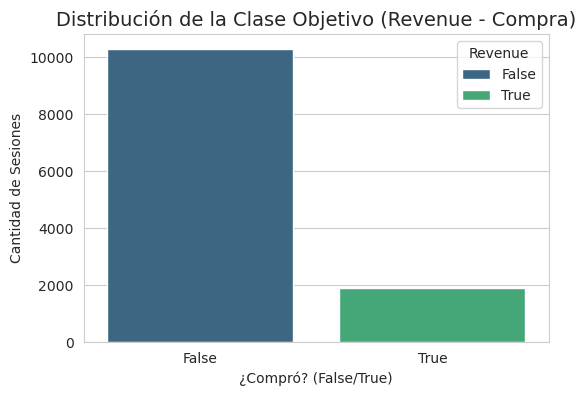

Compras: 15.63%
No Compras: 84.37%


In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Revenue', data=df, palette='viridis', hue='Revenue')
plt.title('Distribución de la Clase Objetivo (Revenue - Compra)', fontsize=14)
plt.xlabel('¿Compró? (False/True)')
plt.ylabel('Cantidad de Sesiones')
plt.show()

compra_ratio = df['Revenue'].value_counts(normalize=True)
print(f"Compras: {compra_ratio.iloc[1]*100:.2f}%")
print(f"No Compras: {compra_ratio.iloc[0]*100:.2f}%")

- El dataset está desbalanceado

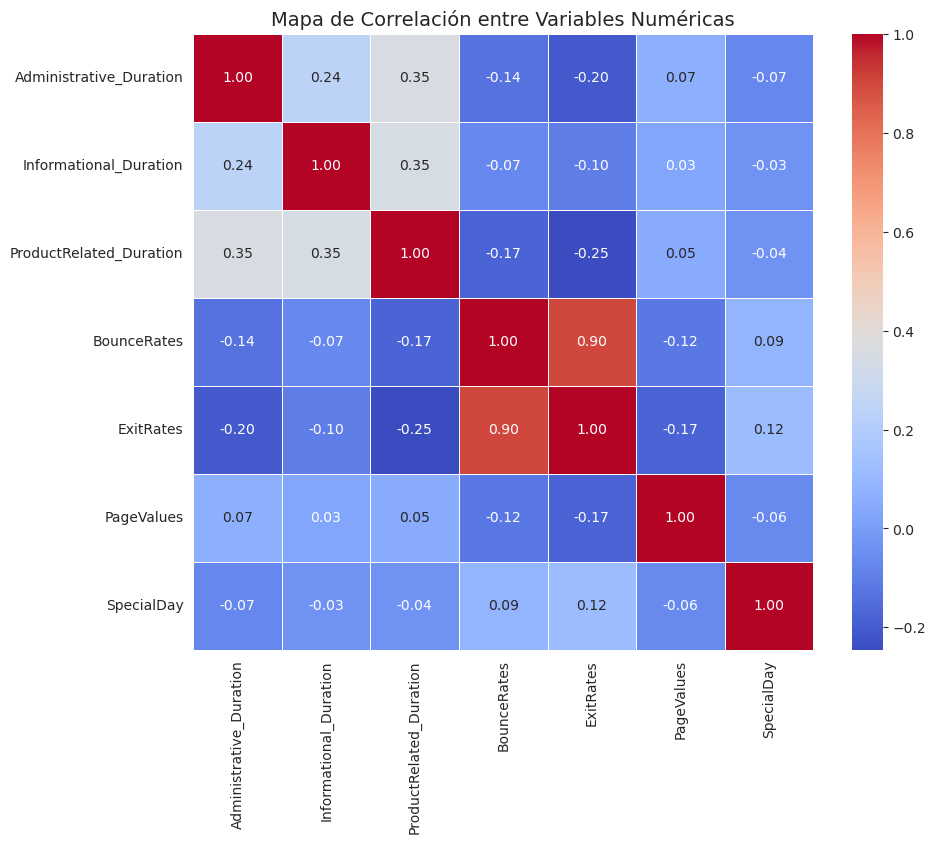

In [11]:
# Seleccionamos solo las columnas numéricas principales para el mapa de calor
cols_numericas = ['Administrative_Duration', 'Informational_Duration', 
                  'ProductRelated_Duration', 'BounceRates', 'ExitRates', 
                  'PageValues', 'SpecialDay']

plt.figure(figsize=(10, 8))
# Calculamos la correlación
corr_matrix = df[cols_numericas].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Correlación entre Variables Numéricas', fontsize=14)
plt.show()

- Alta correlación entre 'BounceRates' y 'ExitRates'

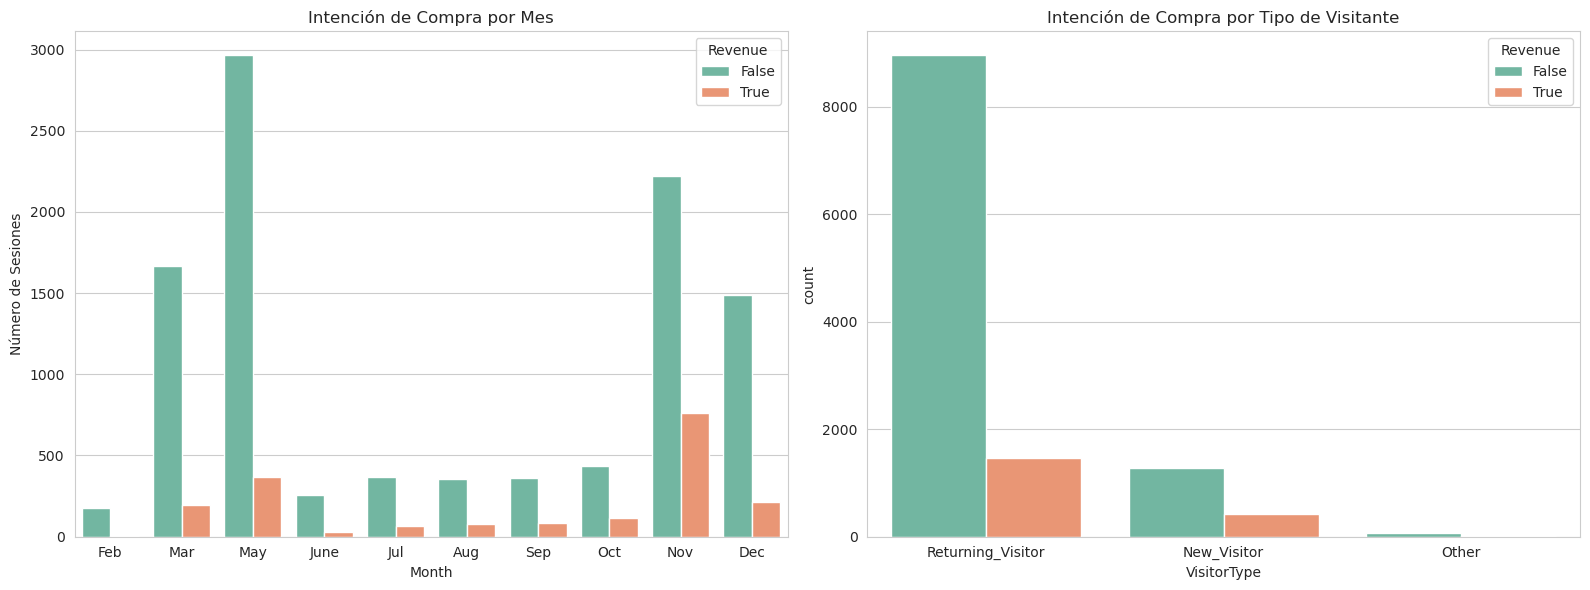

In [12]:
# analisis categorico con la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ventas por Mes
sns.countplot(x='Month', hue='Revenue', data=df, 
              order=['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
              palette='Set2', ax=axes[0])
axes[0].set_title('Intención de Compra por Mes')
axes[0].set_ylabel('Número de Sesiones')

# Ventas por Tipo de Visitante
sns.countplot(x='VisitorType', hue='Revenue', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Intención de Compra por Tipo de Visitante')

plt.tight_layout()
plt.show()

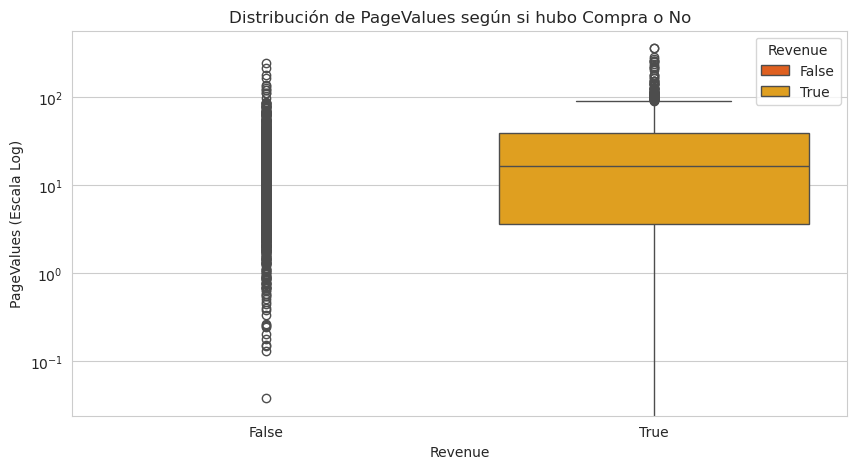

In [13]:
# detectar outliers en PageValues
plt.figure(figsize=(10, 5))
sns.boxplot(x='Revenue', y='PageValues', data=df, palette='autumn', hue='Revenue')
plt.title('Distribución de PageValues según si hubo Compra o No')
plt.yscale('log') # Escala logarítmica para ver mejor porque hay muchos ceros
plt.ylabel('PageValues (Escala Log)')
plt.show()

## Creación y Entrenamiento del Modelo de Red Neuronal Densa

In [14]:
# pre procesamiento de datos

# Convertir booleanos a 0 y 1
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

# Encoding de variables categóricas (Month, VisitorType) usando One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

# Separar Features (X) y Target (y)
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

# Convertir a flotantes
X = X.astype('float32')

# Dividir en Train y Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a tensores de TensorFlow
X_train_tensor = tf.convert_to_tensor(X_train_scaled, dtype=tf.float32)
X_test_tensor = tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)
y_train_tensor = tf.convert_to_tensor(y_train.values, dtype=tf.float32)
y_test_tensor = tf.convert_to_tensor(y_test.values, dtype=tf.float32)

print(f"Forma de los datos de entrada: {X_train_tensor.shape}")

Forma de los datos de entrada: (9764, 26)


In [15]:
# crear y entrenar el modelo de red neuronal

model = Sequential([
    # Capa de entrada (tantas neuronas como columnas tengamos)
    Dense(64, activation='relu', input_shape=(X_train_tensor.shape[1],)),
    Dropout(0.2), # Para evitar overfitting
    
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    Dense(16, activation='relu'),
    
    # Capa de salida (1 neurona con sigmoide porque es clasificación binaria: Compra SI/NO)
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [17]:
# 1. Calcular los pesos basados en tus datos de entrenamiento
# Nota: y_train debe ser tu vector de etiquetas antes de convertirlo a tensor, 
# o puedes usar y_train.values si es una Serie de pandas.
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train), 
    y=y_train
)

# Convertirlo a un diccionario para Keras
class_weights_dict = dict(enumerate(class_weights))

print(f"Pesos calculados: {class_weights_dict}")

Pesos calculados: {0: 0.5940618155268922, 1: 3.1578266494178524}


In [18]:
# entrenar el modelo
history = model.fit(
    X_train_tensor, 
    y_train_tensor,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    class_weight=class_weights_dict 
)

Epoch 1/20
245/245 [==============================] - 1s 2ms/step - loss: 0.5484 - accuracy: 0.7231 - val_loss: 0.3707 - val_accuracy: 0.8500
Epoch 2/20
245/245 [==============================] - 0s 2ms/step - loss: 0.4534 - accuracy: 0.7853 - val_loss: 0.3666 - val_accuracy: 0.8469
Epoch 3/20
245/245 [==============================] - 0s 2ms/step - loss: 0.4285 - accuracy: 0.7959 - val_loss: 0.3692 - val_accuracy: 0.8402
Epoch 4/20
245/245 [==============================] - 0s 2ms/step - loss: 0.4100 - accuracy: 0.8146 - val_loss: 0.3444 - val_accuracy: 0.8592
Epoch 5/20
245/245 [==============================] - 0s 2ms/step - loss: 0.3921 - accuracy: 0.8249 - val_loss: 0.3310 - val_accuracy: 0.8669
Epoch 6/20
245/245 [==============================] - 0s 2ms/step - loss: 0.3904 - accuracy: 0.8302 - val_loss: 0.3134 - val_accuracy: 0.8720
Epoch 7/20
245/245 [==============================] - 0s 2ms/step - loss: 0.3792 - accuracy: 0.8300 - val_loss: 0.3279 - val_accuracy: 0.8592
Epoch 

77/77 [==============================] - 0s 729us/step
--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2079
           1       0.59      0.74      0.66       362

    accuracy                           0.88      2441
   macro avg       0.77      0.82      0.79      2441
weighted avg       0.90      0.88      0.89      2441



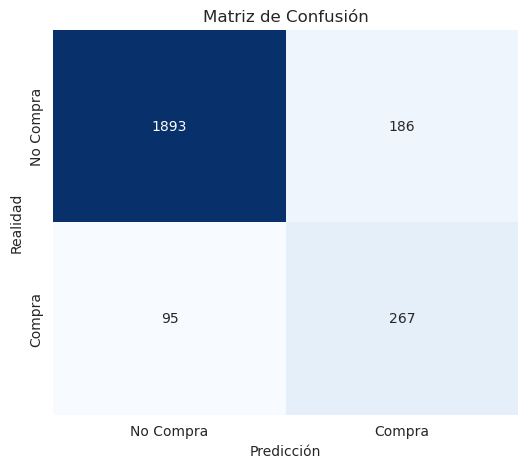

In [35]:
# 1. Obtener las predicciones crudas (probabilidades)
y_pred_probs = model.predict(X_test_tensor)

# 2. Convertir probabilidades a clases (0 o 1) usando un umbral de 0.7
y_pred = (y_pred_probs > 0.7).astype(int)

# 3. Imprimir el reporte completo
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# 4. Visualizar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión')
plt.xticks([0.5, 1.5], ['No Compra', 'Compra'])
plt.yticks([0.5, 1.5], ['No Compra', 'Compra'])
plt.show()

## Explicación de Predicciones con Gradients Integrados

In [36]:
def get_integrated_gradients(input_sample, baseline=None, num_steps=50):
    """
    Calcula los Gradientes Integrados para una muestra de entrada.
    """

    # Si no hay baseline, usamos ceros (el "apagado" del dimmer)
    if baseline is None:
        baseline = tf.zeros_like(input_sample)
    
    # pasos de interpolación
    alphas = tf.linspace(start=0.0, stop=1.0, num=num_steps+1)
    
    # forma correcta para broadcasting: (num_steps, num_features)
    alphas_x = alphas[:, tf.newaxis] 
    delta = input_sample - baseline
    images = baseline +  alphas_x * delta

    # calcular gradientes para cada paso interpolado
    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images)
        
    grads = tape.gradient(predictions, images)
    
    # aproximación de la integral (Promedio de gradientes * delta)
    avg_grads = tf.reduce_mean(grads, axis=0)
    integrated_grads = delta * avg_grads
    
    return integrated_grads.numpy()

In [37]:
def visualizar_importancia(feature_names, importances):
    """
    Grafica qué columnas fueron más importantes para la decisión.
    """

    # dataFrame para ordenar
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # ordenar por valor absoluto (importa tanto lo positivo como lo negativo)
    feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
    feature_importance = feature_importance.sort_values('Abs_Importance', ascending=False).head(15) # Top 15
    
    plt.figure(figsize=(10, 6))
    # verde para impacto positivo, rojo para negativo
    colors = ['green' if x > 0 else 'red' for x in feature_importance['Importance']]
    
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
    plt.xlabel("Contribución a la Predicción (Integrated Gradients)")
    plt.title("Top 15 Variables que influyeron en la decisión del modelo")
    plt.gca().invert_yaxis() # La más importante arriba
    plt.show()

### Ejecución de la explicación

#### Explicación para clientes individuales

In [62]:
def explicar_cliente(idx, model, X_tensor, y_tensor, feature_names, umbral=0.7):
    """
    Toma un índice, predice, calcula IG y grafica la importancia.
    """
    # Extraer datos del cliente
    cliente_sample = X_tensor[idx]
    etiqueta_real = int(y_tensor[idx])
    
    # Predecir
    # Expandimos dimensiones porque el modelo espera un lote (batch) de datos
    pred_prob = model.predict(tf.expand_dims(cliente_sample, axis=0), verbose=0)[0][0]
    pred_clase = 1 if pred_prob > umbral else 0
    
    print(f"\nAnálisis del Cliente #{idx}")
    print(f"Probabilidad de Compra: {pred_prob:.4f} ({pred_prob*100:.2f}%)")
    print(f"Predicción (Umbral {umbral}): {'COMPRA' if pred_clase == 1 else 'NO COMPRA'}")
    print(f"Realidad: {'COMPRA' if etiqueta_real == 1 else 'NO COMPRA'}")
    
    # Calcular Gradientes Integrados
    ig_attributions = get_integrated_gradients(cliente_sample)
    
    # Visualizar
    visualizar_importancia(feature_names, ig_attributions)


--- Análisis del Cliente #1 ---
Probabilidad de Compra: 0.8539 (85.39%)
Predicción (Umbral 0.7): COMPRA
Realidad: COMPRA


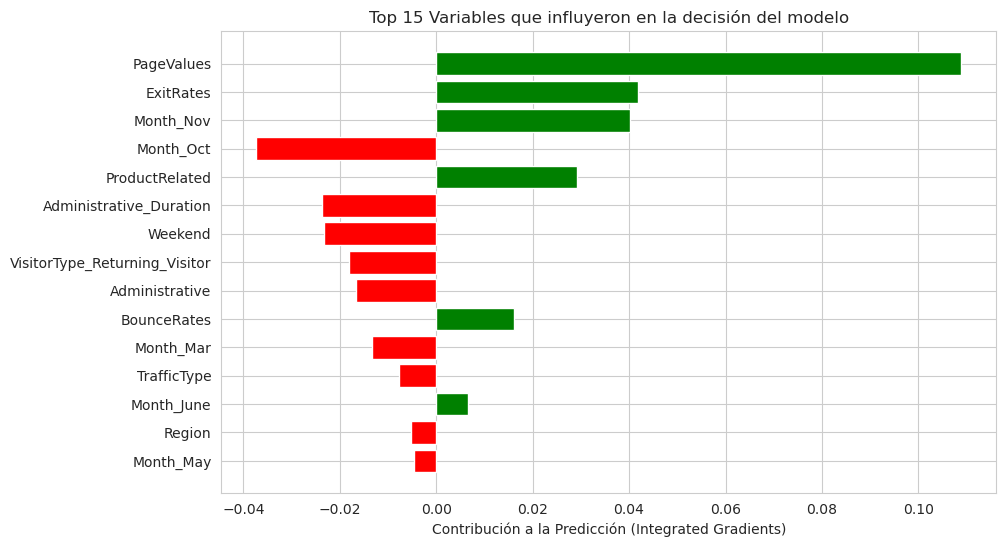

In [50]:
# cliente 1
explicar_cliente(1, model, X_test_tensor, y_test_tensor, X.columns)


--- Análisis del Cliente #745 ---
Probabilidad de Compra: 0.8690 (86.90%)
Predicción (Umbral 0.7): COMPRA
Realidad: COMPRA


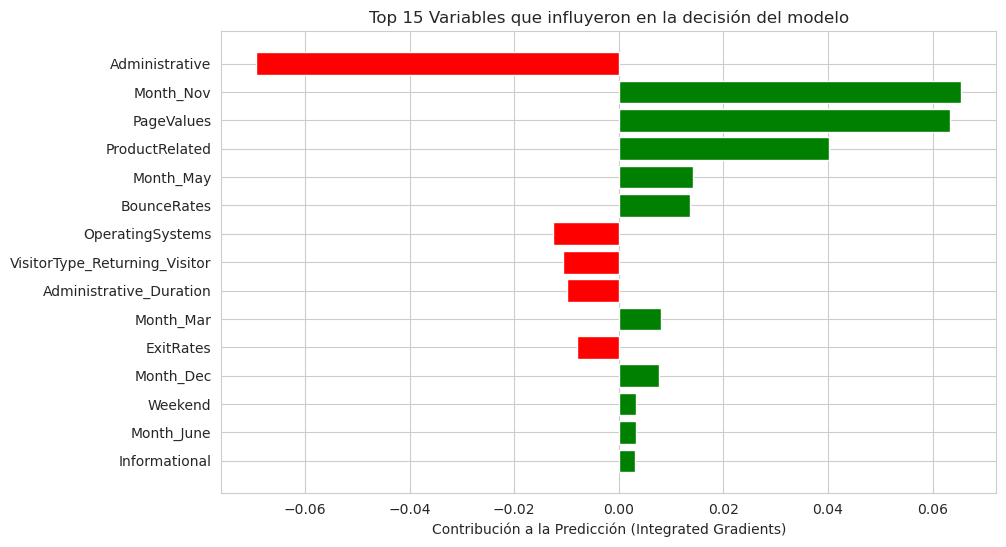

In [58]:
# cliente 100
explicar_cliente(745, model, X_test_tensor, y_test_tensor, X.columns)


--- Análisis del Cliente #100 ---
Probabilidad de Compra: 0.0329 (3.29%)
Predicción (Umbral 0.7): NO COMPRA
Realidad: NO COMPRA


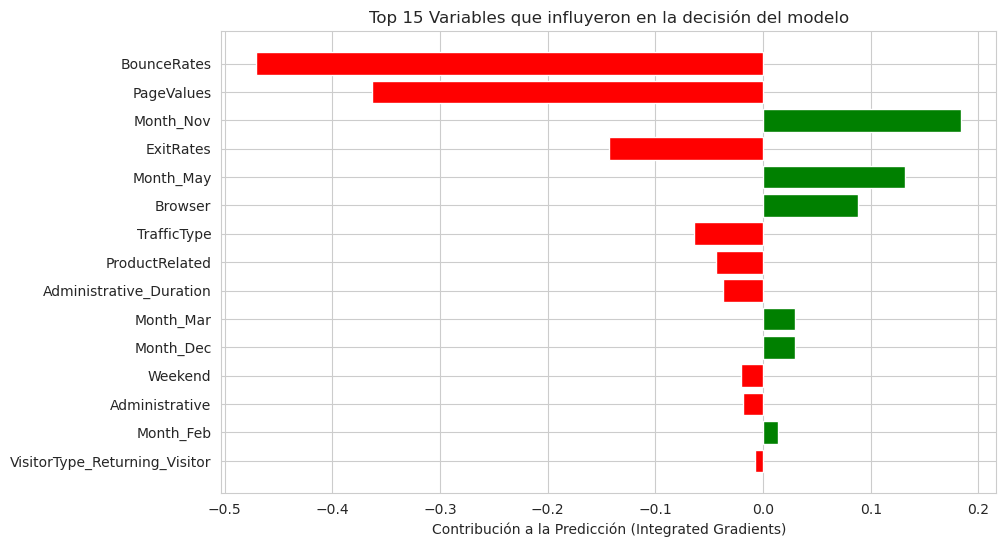

In [52]:
# cliente 100
explicar_cliente(100, model, X_test_tensor, y_test_tensor, X.columns)


--- Análisis del Cliente #341 ---
Probabilidad de Compra: 0.3740 (37.40%)
Predicción (Umbral 0.7): NO COMPRA
Realidad: NO COMPRA


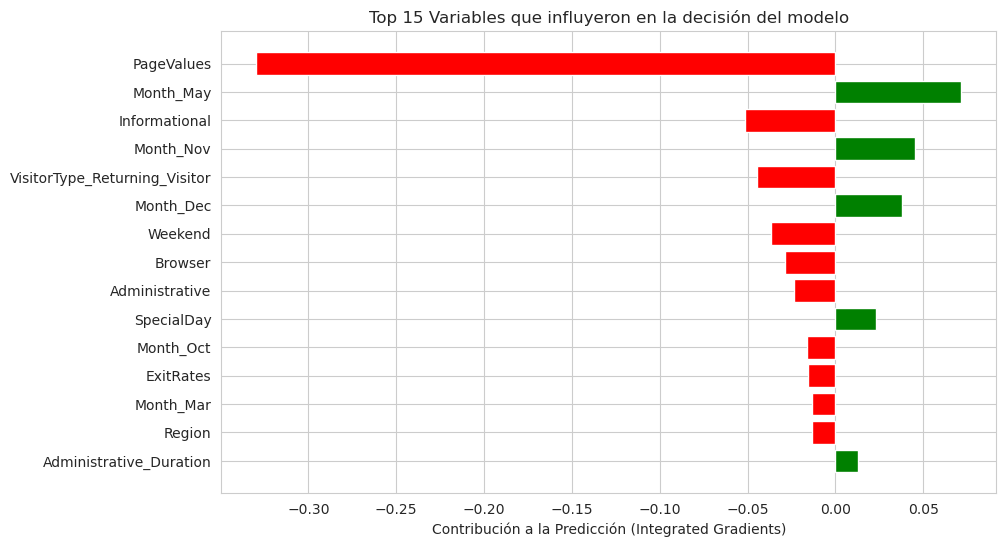

In [59]:
# cliente 341
explicar_cliente(341, model, X_test_tensor, y_test_tensor, X.columns)

#### Explicación para clientes globalmente

In [60]:
def analizar_importancia_global(model, X_tensor, feature_names, sample_size=100):
    print(f"Calculando importancia global basada en {sample_size} muestras...")
    
    # Seleccionamos índices aleatorios para no tardar una eternidad calculando todo el dataset
    indices_aleatorios = np.random.choice(X_tensor.shape[0], sample_size, replace=False)
    
    acumulado_gradientes = np.zeros(X_tensor.shape[1])
    
    for i in indices_aleatorios:
        # Sumamos el valor ABSOLUTO de los gradientes. 
        grads = get_integrated_gradients(X_tensor[i])
        acumulado_gradientes += np.abs(grads)
        
    # Promediamos
    promedio_importancia = acumulado_gradientes / sample_size
    
    # Graficamos
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Abs_Importance': promedio_importancia
    })
    
    feature_importance = feature_importance.sort_values('Abs_Importance', ascending=True).tail(15)
    
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance['Feature'], feature_importance['Abs_Importance'], color='teal')
    plt.xlabel("Importancia Promedio (Magnitud de Gradientes)")
    plt.title(f"Top 15 Variables Más Importantes en General (Muestra: {sample_size})")
    plt.show()

Calculando importancia global basada en 200 muestras...


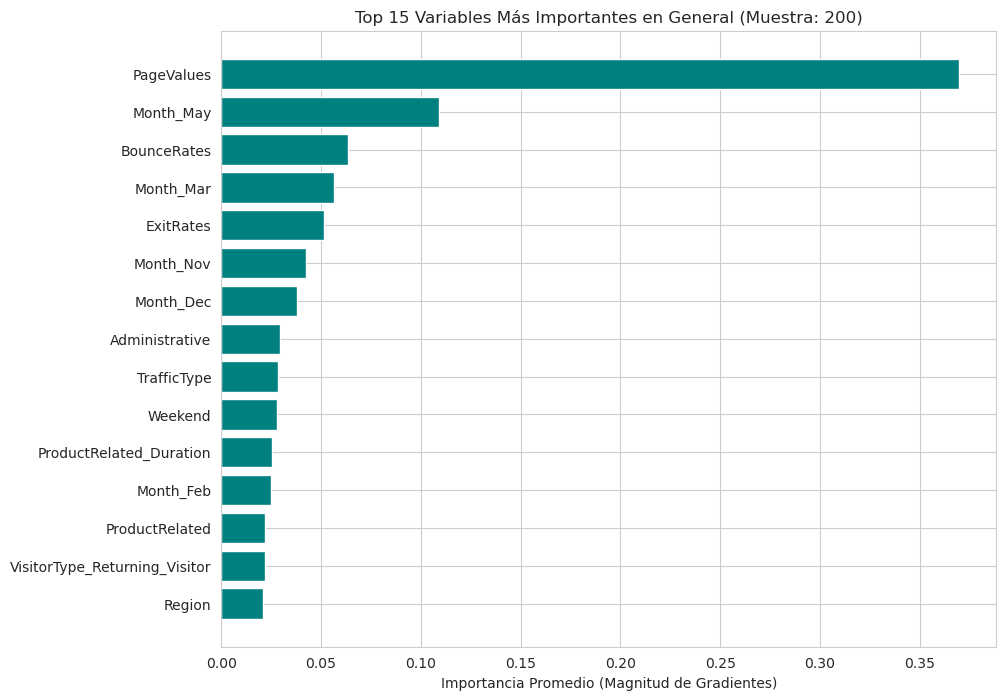

In [61]:
analizar_importancia_global(model, X_test_tensor, X.columns, sample_size=200)

## **Resultados**

#### Desempeño del Modelo

Tras entrenar la Red Neuronal Densa abordando el desbalanceo de clases mediante class_weights (pesando la clase minoritaria ~3.15 veces más ), y ajustando el umbral de decisión a 0.7, obtuvimos los siguientes resultados:

* Accuracy Global: 88%. El modelo acierta en la gran mayoría de los casos.
* Recall (Sensibilidad) para Compras: 74%. De todos los clientes que realmente compraron, el modelo fue capaz de detectar correctamente a casi 3 de cada 4. Esto es un logro significativo dado que originalmente solo representan el 15% del dataset.
* Precision para Compras: 59%. Cuando el modelo predice que alguien comprará, acierta el 59% de las veces. Al subir el umbral de 0.5 a 0.7, logramos reducir falsos positivos, haciendo las predicciones más confiables.

#### Análisis de Importancia (Global vs. Local)

Gracias a la técnica de Gradients Integrados, descubrimos patrones claros:

1. A Nivel Global: Al analizar una muestra de 200 clientes, la variable PageValues (valor promedio de las páginas visitadas) es, por lejos, el predictor más potente. Le siguen la estacionalidad (Month_May, Month_Nov) y las tasas de rebote (BounceRates).

2. A Nivel Local:
* En el Cliente #1 (Comprador), el modelo basó su decisión casi exclusivamente en un alto PageValues y en que la visita fue en Noviembre (Month_Nov), lo cual compensó factores negativos como Month_Oct .
* En el Cliente #100 (No Comprador), el modelo penalizó fuertemente el BounceRates (Tasa de Rebote alta) y el hecho de visitar en Mayo (Month_May), llevándolo a predecir correctamente la "No Compra".

## **Explicación de Predicciones con Gradients Integrados**

#### ¿Qué son los Gradients Integrados?

Las redes neuronales profundas suelen comportarse como "cajas negras": sabemos qué entra y qué sale, pero es difícil entender por qué toman ciertas decisiones. Para solucionar esto, utilizamos Integrated Gradients (IG), un método de atribución axiomática que asigna una puntuación de importancia a cada característica de entrada (*feature*) basándose en cuánto contribuyó a la predicción final.

#### ¿Cómo funciona?

La técnica se basa en calcular la integral de los gradientes de la salida del modelo con respecto a la entrada, a lo largo de un camino lineal. El proceso implementado en este trabajo sigue estos pasos:

1. Línea Base (Baseline): Definimos un punto de partida "neutral", en nuestro caso un vector de ceros (tf.zeros_like), que representa la ausencia de información (como una imagen en negro o un cliente "vacío").

2. Interpolación: Generamos una serie de pasos intermedios (alphas) que van gradualmente desde la *Línea Base* hasta el dato del *Cliente Real*. Es como usar un "dimmer" de luz que va subiendo la intensidad de las variables poco a poco.

3. Cálculo de Gradientes: Para cada paso interpolado, calculamos los gradientes de la predicción. Esto nos dice: *"En este punto exacto de intensidad, ¿cuánto cambia la probabilidad de compra si aumentamos ligeramente esta variable?"*.

4. Integración (Promedio): Promediamos todos los gradientes calculados a lo largo del camino y los multiplicamos por la diferencia entre la entrada real y la línea base. Esto nos da la atribución final.

El resultado nos indica no solo qué variables importan (magnitud), sino cómo afectan (signo):

* Valor Positivo (Verde): La variable empujó al modelo hacia la predicción de "COMPRA".
* Valor Negativo (Rojo): La variable empujó al modelo hacia "NO COMPRA".

## **Conclusiones**

1. Efectividad ante el Desbalanceo: Se demostró que es posible entrenar una red neuronal efectiva en un dataset altamente desbalanceado (85/15) sin necesidad de crear datos sintéticos (como con la librería SMOTE), utilizando simplemente una estrategia de ponderación de clases (class_weights). Esto permitió mantener un Recall alto (74%) sin sacrificar excesivamente la precisión.
2. Transparencia del Modelo: La implementación de Gradients Integrados transformó un modelo de "caja negra" en una herramienta explicable. Esto es crucial para el negocio, ya que permite confiar en las predicciones al validar que el modelo sigue una lógica coherente (ej. valorar más a usuarios que visitan páginas de alto valor).
3. Insights de Negocio:
    * El contenido es rey: La predominancia de PageValues sugiere que la calidad del contenido y las páginas de producto son determinantes para la conversión.
    * Factor Temporal: La influencia de meses específicos (Noviembre positivo, Mayo a veces negativo) indica una fuerte estacionalidad que debe ser aprovechada en campañas de marketing.
    * Señales de Alerta: Una alta Tasa de Rebote (BounceRates) es el indicador más claro de un cliente que no comprará, actuando como un "freno" fuerte en la red neuronal.